# Average Shortest Paths Simple Trading Strategy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

**Strategy**
- When the positive average shortest paths is higher than the negative average shortest paths buy/hold. Otherwise sell.
- Will start with $1000 for each stock.
- Buying will use up all capital for that stock and selling will sell all units of a stock.

In [2]:
NUM_COL = 'dlyclose'
DATE_COL = 'dlycaldt'
TICKER_COL1 = 'permno'
TICKER_COL2 = 'ticker'
START_BALANCE = 1000
EXIT_PROP = 1.0
LOOKBACK=7

In [3]:
avsp = pd.read_csv('./data/all_avsp_crsp_window_7.csv')
avsp[DATE_COL] = pd.to_datetime(avsp[DATE_COL])
avsp.head()

,dlycaldt,permno,ticker,pos,neg,dlyclose
0,2010-01-13,10001,EGAS,2.000000,1.380952,10.37
1,2010-01-14,10001,EGAS,2.000000,1.333333,10.35
2,2010-01-15,10001,EGAS,2.285714,1.190476,10.27
3,2010-01-19,10001,EGAS,2.238095,1.238095,10.15
4,2010-01-20,10001,EGAS,1.523810,1.523810,10.27


##### Initial Exploration

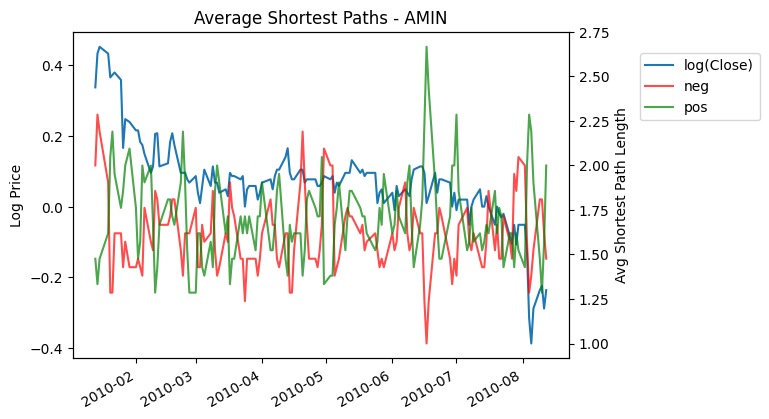

In [16]:
ticker1 = 92212
ticker2 = "AMIN"
df = avsp[(avsp[TICKER_COL1] == ticker1) & (avsp[TICKER_COL2] == ticker2)].set_index(DATE_COL)

fig, ax1 = plt.subplots()

ax1.plot(np.log(df[NUM_COL]), label="log(Close)")
ax1.set_ylabel("Log Price")

ax2 = ax1.twinx()
ax2.plot(df["neg"], color="red", label="neg", alpha=0.7)
ax2.plot(df["pos"], color="green", label="pos", alpha=0.7)
ax2.set_ylabel("Avg Shortest Path Length")

fig.legend(loc="upper left", bbox_to_anchor=(1, 0.85))
plt.title(f"Average Shortest Paths - {df['ticker'].values[0]}")
plt.xticks(rotation=45)
fig.autofmt_xdate() 
plt.show()

In [17]:
curr_b = START_BALANCE
curr_vol = 0
### Full Exit
exit_prop = EXIT_PROP
returns = []

for _, row in df.iterrows():

    pos = row['pos']
    neg = row['neg']
    num = row[NUM_COL]

    # Buy signal
    if pos >= neg:
        ### Only buy if we have balance
        ### Otherwise we will just be holding the stock
        if curr_b > 0:
            curr_vol += curr_b / num
            curr_b = 0

    # Sell signal
    else:
        ### Only sell if we have volume to sell
        if curr_vol > 0:
            shares_sold = exit_prop * curr_vol
            curr_b += shares_sold * num
            curr_vol -= shares_sold
            
    ### Current Return of the Strategy
    ### Cash Balance + Value of Held Stock
    returns.append(curr_b + curr_vol * num)

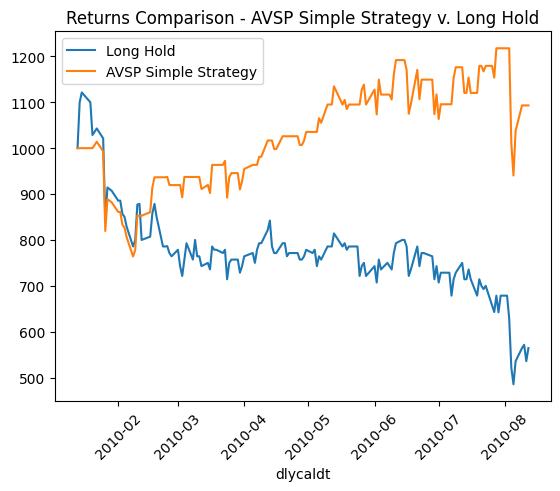

In [23]:
start_vol = START_BALANCE / df[NUM_COL].iloc[0]

hold_ret = start_vol * df[NUM_COL].values

sns.lineplot(x=df.index, y=hold_ret, label="Long Hold")
sns.lineplot(x=df.index, y=returns, label="AVSP Simple Strategy")

plt.title("Returns Comparison - AVSP Simple Strategy v. Long Hold")
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### Function Development

In [24]:
def avsp_simple_strat_single(df, curr_b=1000, exit_prop=1.0):
    ### Defaults to starting balance of 1000 and full exits
    curr_vol = 0

    returns = []

    for _, row in df.iterrows():

        pos = row['pos']
        neg = row['neg']
        num = row[NUM_COL]

        ### Buy signal
        if pos >= neg:
            ### Only buy if we have balance
            ### Otherwise we will just be holding the stock
            if curr_b > 0:
                curr_vol += curr_b / num
                curr_b = 0

        ### Sell signal
        else:
            ### Only sell if we have volume to sell
            if curr_vol > 0:
                shares_sold = exit_prop * curr_vol
                curr_b += shares_sold * num
                curr_vol -= shares_sold
                
        ### Current Return of the Strategy
        ### Cash Balance + Value of Held Stock
        returns.append(curr_b + curr_vol * num)
    
    return returns

In [25]:
def avsp_simple_strat(data, tickers, curr_b=START_BALANCE, exit_prop=EXIT_PROP):
    ret_df = pd.DataFrame()
    for t in tickers:
        df = data[(data[TICKER_COL1] == t[0]) & (data[TICKER_COL2] == t[1])].reset_index(drop=True)
        returns = avsp_simple_strat_single(df, curr_b=curr_b, exit_prop=exit_prop)
        start_vol = START_BALANCE / df[NUM_COL].iloc[0]
        hold_ret = start_vol * df[NUM_COL].values
        stg_df = (
            df[[TICKER_COL1, TICKER_COL2, DATE_COL]]
            .copy()
            .assign(
                strat_ret=returns,
                hold_ret=hold_ret
            )
        )
        if len(ret_df) == 0:
            ret_df = stg_df.copy()
        else:
            ret_df = pd.concat([ret_df, stg_df])
    
    return ret_df

In [26]:
data = avsp.copy()
tickers = data[[TICKER_COL1, TICKER_COL2]].drop_duplicates().values
ret_df = avsp_simple_strat(data, tickers)
ret_df.to_csv(f"./data/all_avsp_simple_rets_window_{LOOKBACK}.csv", index=False)

# ret_df = pd.read_csv(f"./data/all_avsp_simple_rets_window_{LOOKBACK}.csv")
# ret_df[DATE_COL] = pd.to_datetime(ret_df[DATE_COL])

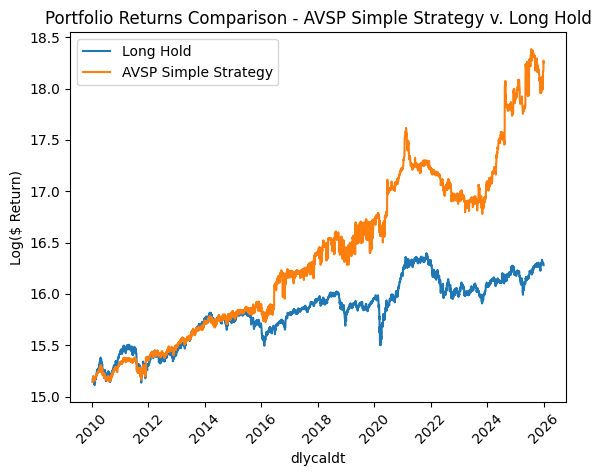

In [27]:
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum"})

sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="AVSP Simple Strategy")

plt.title("Portfolio Returns Comparison - AVSP Simple Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

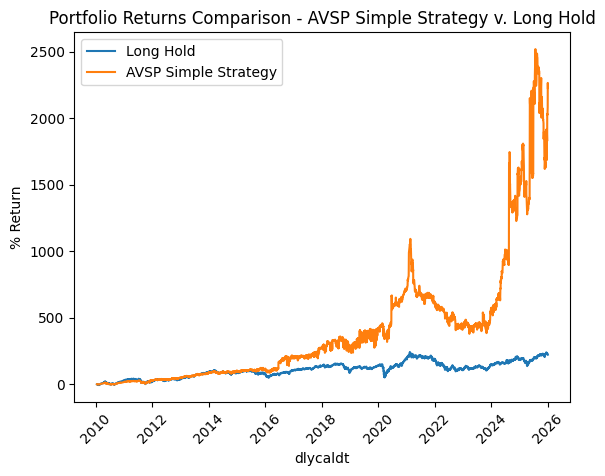

In [29]:
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum", TICKER_COL1 : "count"}).rename(columns={TICKER_COL1:"num_stocks"})
plot_df['base_bal'] = plot_df["num_stocks"] * START_BALANCE
plot_df["strat_pct_grwth"] = (plot_df["strat_ret"] / plot_df['base_bal'] - 1) * 100
plot_df["hold_pct_grwth"] = (plot_df["hold_ret"] / plot_df['base_bal'] - 1) * 100

sns.lineplot(x=plot_df.index, y=plot_df['hold_pct_grwth'], label="Long Hold")
sns.lineplot(x=plot_df.index, y=plot_df['strat_pct_grwth'], label="AVSP Simple Strategy")

plt.title("Portfolio Returns Comparison - AVSP Simple Strategy v. Long Hold")
plt.ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.show()

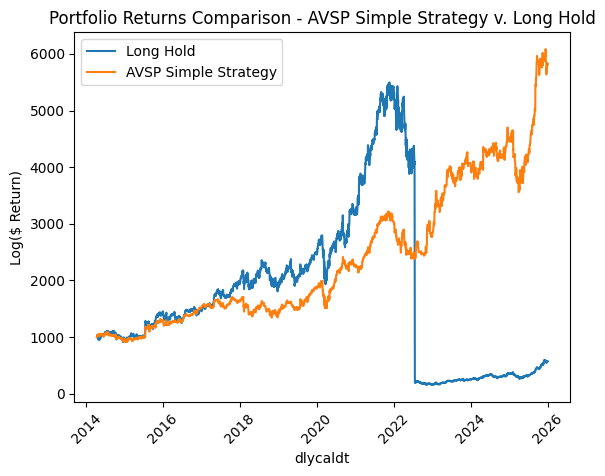

In [40]:
t = "GOOGL"
plot_df = ret_df[ret_df['ticker'] == t]

sns.lineplot(x=plot_df[DATE_COL], y=plot_df['hold_ret'], label="Long Hold")
sns.lineplot(x=plot_df[DATE_COL], y=plot_df['strat_ret'], label="AVSP Simple Strategy")

plt.title("Portfolio Returns Comparison - AVSP Simple Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [41]:
plot_df

,permno,ticker,dlycaldt,strat_ret,hold_ret
0,90319,GOOGL,2014-04-14,1000.000000,1000.000000
1,90319,GOOGL,2014-04-15,1006.419663,1006.419663
2,90319,GOOGL,2014-04-16,1034.299340,1034.299340
3,90319,GOOGL,2014-04-17,1034.299340,996.588408
4,90319,GOOGL,2014-04-21,1034.299340,989.306676
...,...,...,...,...,...
2943,90319,GOOGL,2025-12-24,5831.819539,576.100514
2944,90319,GOOGL,2025-12-26,5821.050475,575.036684
2945,90319,GOOGL,2025-12-29,5821.978843,575.128393
2946,90319,GOOGL,2025-12-30,5827.363375,575.660308


In [42]:
data[data['ticker'] == t]

,dlycaldt,permno,ticker,pos,neg,dlyclose
10967974,2014-04-14,90319,GOOGL,1.619048,1.571429,545.20
10967975,2014-04-15,90319,GOOGL,1.666667,1.523810,548.70
10967976,2014-04-16,90319,GOOGL,1.285714,1.857143,563.90
10967977,2014-04-17,90319,GOOGL,1.285714,1.809524,543.34
10967978,2014-04-21,90319,GOOGL,1.428571,1.428571,539.37
...,...,...,...,...,...,...
10970917,2025-12-24,90319,GOOGL,1.571429,1.428571,314.09
10970918,2025-12-26,90319,GOOGL,2.238095,1.142857,313.51
10970919,2025-12-29,90319,GOOGL,2.047619,1.190476,313.56
10970920,2025-12-30,90319,GOOGL,1.666667,1.285714,313.85
